# Exploratory Data Analysis (EDA) – Spam Classifier Dataset 


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

### Examining the dataset

In [2]:
df = pd.read_csv("emails.csv",encoding="latin-1")
df.head(10)

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
5,"Subject: great nnews hello , welcome to medzo...",1
6,Subject: here ' s a hot play in motion homela...,1
7,Subject: save your money buy getting this thin...,1
8,Subject: undeliverable : home based business f...,1
9,Subject: save your money buy getting this thin...,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 89.6 KB


In [4]:
df.duplicated().sum()

np.int64(33)

In [5]:
df["text"] = df["text"].str.lower().str.strip().str.replace("subject:","").str.strip()
df.head(10)

,text,spam
0,naturally irresistible your corporate identity...,1
1,the stock trading gunslinger fanny is merrill...,1
2,unbelievable new homes made easy im wanting t...,1
3,4 color printing special request additional i...,1
4,"do not have money , get software cds from here...",1
5,"great nnews hello , welcome to medzonline sh ...",1
6,here ' s a hot play in motion homeland securi...,1
7,save your money buy getting this thing here y...,1
8,undeliverable : home based business for grownu...,1
9,save your money buy getting this thing here y...,1


In [6]:
df.describe()

,spam
count,5728.000000
mean,0.238827
std,0.426404
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [7]:
df.columns

Index(['text', 'spam'], dtype='str')

In [8]:
df.isnull().any()

text    False
spam    False
dtype: bool

In [9]:
no_of_rows = df.shape[0]
no_of_columns = df.shape[1]
print(f"No. of rows : {no_of_rows}")
print(f"No. of columns : {no_of_columns}")

No. of rows : 5728
No. of columns : 2


Remember this percentage

In [10]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()


np.int64(0)

In [11]:
df.describe()

,spam
count,5695.000000
mean,0.240211
std,0.427249
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [12]:
df.groupby("spam")["text"].count()

spam
0    4327
1    1368
Name: text, dtype: int64

In [13]:
# No. of rows and columns after removing duplicate values 
no_of_rows = df.shape[0]
no_of_columns = df.shape[1]
print("No. of rows and columns after removing duplicate values ")
print(f"No. of rows : {no_of_rows}")
print(f"No. of columns : {no_of_columns}")

No. of rows and columns after removing duplicate values 
No. of rows : 5695
No. of columns : 2


In [14]:
no_of_nonspam = df.groupby("spam")["text"].count()[0]
percentage_nonspam = ((no_of_nonspam/no_of_rows)*100).__round__(3)
print(f"No. of non spam or ham emails : {no_of_nonspam} \nPercentage of non spam or ham : {percentage_nonspam} %")
no_of_spam = df.groupby("spam")["text"].count()[1]
percentage_spam = ((no_of_spam/no_of_rows)*100).__round__(3)
print(f"No. of spam emails : {no_of_spam} \nPercentage of non spam or ham : {percentage_spam} %")

No. of non spam or ham emails : 4327 
Percentage of non spam or ham : 75.979 %
No. of spam emails : 1368 
Percentage of non spam or ham : 24.021 %


### Visualising Dataset

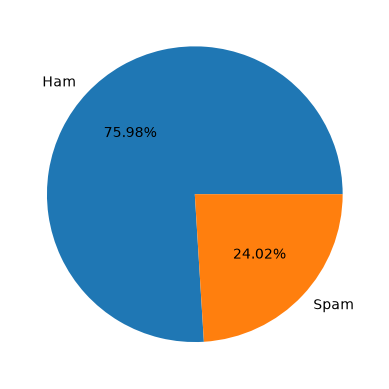

In [15]:
plt.pie([percentage_nonspam,percentage_spam],labels=["Ham","Spam"],autopct="%1.2f%%")

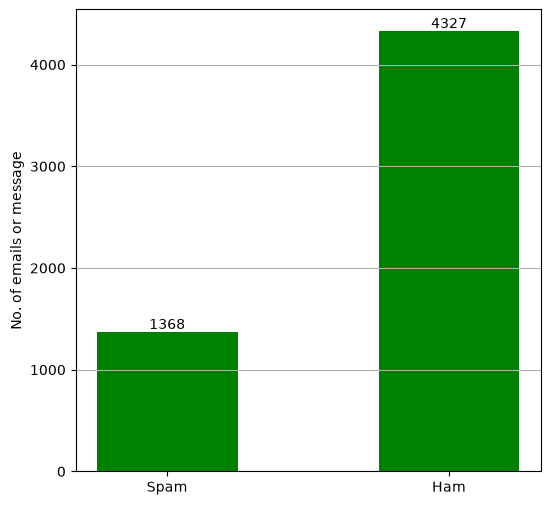

In [16]:
plt.figure(figsize=(6,6))
bars = plt.bar(["Spam","Ham"],[no_of_spam,no_of_nonspam],color="green",width=0.5)
plt.ylabel("No. of emails or message")
plt.bar_label(bars)
plt.grid(axis="y")
plt.show()

# Training Model

### Setting requirements for finding the best model 

In [17]:
X = df["text"]
y = df["spam"]
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)                                        

## List of Model we used :
* LogisticRegression
* KNeighborsClassifier
* DecisionTreeClassifier
* RandomForestClassifier
* SVC

### 1. LogisticRegression

In [18]:
from sklearn.linear_model import LogisticRegression
pipeline_logisticregression = Pipeline([
    ("tfidf",TfidfVectorizer()),
    ("model",LogisticRegression())
])
pipeline_logisticregression.fit(X_train,y_train)
prediction_logisticregression = pipeline_logisticregression.predict(X_test)

### 2. KNeighborsClassifier

In [19]:
from sklearn.neighbors import KNeighborsClassifier
param_grid_knn = {
    "model__n_neighbors": [7, 13, 17 ,21]
}
pipeline_knn = Pipeline([
    ("tfidf",TfidfVectorizer()),
    ("model",KNeighborsClassifier())
])
gridsearch_knn = GridSearchCV(
    pipeline_knn,
    param_grid_knn,
    cv=5,
    scoring="f1"
)
gridsearch_knn.fit(X_train,y_train)
model_knn = gridsearch_knn.best_estimator_
prediction_knn = model_knn.predict(X_test)

### 3. DecisionTreeClassifier

In [20]:
from sklearn.tree import DecisionTreeClassifier
param_grid_decsiontree = {
    "model__max_depth" : [3,5,7,10,15,20,None],
    "model__min_samples_leaf" : [1,2,5,10],
    "model__min_samples_split" : [2,5,10,20]
}
pipeline_decisiontree = Pipeline([
    ("tfidf",TfidfVectorizer()),
    ("model",DecisionTreeClassifier())
])
randomsearch_decesiontree = RandomizedSearchCV(
    pipeline_decisiontree,
    param_grid_decsiontree,
    n_iter= 20,
    cv=5,
    random_state=42,
    scoring="f1"
)
randomsearch_decesiontree.fit(X_train,y_train)
model_decesiontree = randomsearch_decesiontree.best_estimator_
prediction_decesiontree = model_decesiontree.predict(X_test)


### 4. RandomForestClassifier

In [21]:
from sklearn.ensemble import RandomForestClassifier
pipeline_randomforest = Pipeline([
    ("tfidf",TfidfVectorizer()),
    ("model",RandomForestClassifier())
])
param_grid_randomforest = {
    "model__n_estimators" : [50,100,200,300,500],
    "model__max_depth" : [5,10,15,20,None],
    "model__min_samples_leaf" : [1,2,5,10],
    "model__min_samples_split" : [2,5,10,20]
}
randomsearch_randomforest = RandomizedSearchCV(
    pipeline_randomforest,
    param_grid_randomforest,
    n_iter=15,
    cv=5,
    random_state=42,
    scoring="f1"
)
randomsearch_randomforest.fit(X_train,y_train)
model_randomforest = randomsearch_randomforest.best_estimator_
prediction_randomforest = model_randomforest.predict(X_test)

### 5. SVC

In [22]:
from sklearn.svm import SVC
pipeline_svc = Pipeline([
    ("tfidf",TfidfVectorizer()),
    ("model",SVC())
])
param_grid_svc = {
    "model__C":[0.1,1,10,100],
    "model__gamma":[0.001,0.01,0.1,1],
    "model__kernel":["rbf","linear"]
}
randomsearch_svc = RandomizedSearchCV(
    pipeline_svc,
    param_grid_svc,
    n_iter=10,
    cv=5,
    random_state=42,
    scoring="f1"
)
randomsearch_svc.fit(X_train,y_train)
model_svc = randomsearch_svc.best_estimator_
prediction_svc = model_svc.predict(X_test)

## Compairing all models to find the best model

In [23]:
from sklearn.metrics import (accuracy_score, precision_score,recall_score,f1_score ,confusion_matrix)
models_name = ["LogisticRegression","KNeighborsClassifier","DecisionTreeClassifier","RandomForestClassifier","SVC"]
z = [prediction_logisticregression,prediction_knn,prediction_decesiontree,prediction_randomforest,prediction_svc]
for i in range(len(z)):
    print(f"{models_name[i]} confusion matrix : ")
    cm = confusion_matrix(y_test,z[i])
    print(cm)

LogisticRegression confusion matrix : 
[[865   0]
 [ 17 257]]
KNeighborsClassifier confusion matrix : 
[[848  17]
 [ 12 262]]
DecisionTreeClassifier confusion matrix : 
[[835  30]
 [ 19 255]]
RandomForestClassifier confusion matrix : 
[[865   0]
 [ 29 245]]
SVC confusion matrix : 
[[863   2]
 [  2 272]]


If we analyse the above matrices we can see that SVC is making the least possible mistakes on test data. so it can be our best model.

In [24]:
from sklearn.metrics import (accuracy_score, precision_score,recall_score,f1_score ,confusion_matrix)
df_comp_models = pd.DataFrame(
    index=models_name,
    columns=[" accuracy_score ", " precision_score "," recall_score "," f1_score"]
)
z = [prediction_logisticregression,prediction_knn,prediction_decesiontree,prediction_randomforest,prediction_svc]
for i in range(len(z)):
    df_comp_models.iloc[i] = [
        accuracy_score(y_test, z[i]),
        precision_score(y_test, z[i]),
        recall_score(y_test, z[i]),
        f1_score(y_test, z[i])
    ]
df_comp_models

,accuracy_score,precision_score,recall_score,f1_score
LogisticRegression,0.985075,1.0,0.937956,0.967985
KNeighborsClassifier,0.974539,0.939068,0.956204,0.947559
DecisionTreeClassifier,0.95698,0.894737,0.930657,0.912343
RandomForestClassifier,0.974539,1.0,0.894161,0.944123
SVC,0.996488,0.992701,0.992701,0.992701


### Checking if SVC model is overfitted or not

In [25]:
print("Best CV F1:", randomsearch_svc.best_score_)
print("Test F1:", f1_score(y_test, prediction_svc))

Best CV F1: 0.9885309149453851
Test F1: 0.9927007299270073


As we can see that the our average f1 score of cross-validated result and f1 score of cross-validated predicted result both are having very very small difference. Hence it is not overfitted.

## Final model

In [26]:
model = model_svc